## Курсовая работа

#### Задание:

**Используя данные из обучающего датасета (train.csv), построить модель для предсказания цен на недвижимость (квартиры).
С помощью полученной модели, предсказать цены для квартир из тестового датасета (test.csv).**

**Целевая переменная:**
Price

**Метрика качества:**
R2 - коэффициент детерминации (sklearn.metrics.r2_score)

**Требования к решению:**
1. R2 > 0.6
2. Тетрадка Jupyter Notebook с кодом Вашего решения, названная по образцу {ФИО}_solution.ipynb, пример SShirkin_solution.ipynb
3. Файл CSV с прогнозами целевой переменной для тестового датасета, названный по образцу {ФИО}_predictions.csv, пример SShirkin_predictions.csv 
Файл должен содержать два поля: Id, Price и в файле должна быть 5001 строка (шапка + 5000 предсказаний).

**Рекомендации для файла с кодом (ipynb):**
1. Файл должен содержать заголовки и комментарии (markdown)
2. Повторяющиеся операции лучше оформлять в виде функций
3. Не делать вывод большого количества строк таблиц (5-10 достаточно)
4. По возможности добавлять графики, описывающие данные (около 3-5)
5. Добавлять только лучшую модель, то есть не включать в код все варианты решения проекта
6. Скрипт проекта должен отрабатывать от начала и до конца (от загрузки данных до выгрузки предсказаний)
7. Весь проект должен быть в одном скрипте (файл ipynb).

**Описание датасета:**
* **Id** - идентификационный номер квартиры
* **DistrictId** - идентификационный номер района
* **Rooms** - количество комнат
* **Square** - площадь
* **LifeSquare** - жилая площадь
* **KitchenSquare** - площадь кухни
* **Floor** - этаж
* **HouseFloor** - количество этажей в доме
* **HouseYear** - год постройки дома
* **Ecology_1, Ecology_2, Ecology_3** - экологические показатели местности
* **Social_1, Social_2, Social_3** - социальные показатели местности
* **Healthcare_1, Helthcare_2** - показатели местности, связанные с охраной здоровья
* **Shops_1, Shops_2** - показатели, связанные с наличием магазинов, торговых центров
* **Price** - цена квартиры

### EDA

In [1]:
import numpy as np
import pandas as pd

import matplotlib
import matplotlib.image as img
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from catboost import CatBoostRegressor, Pool
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
import joblib
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams.update({'font.size': 14})  # размер шрифта на графиках

Загрузим данные и посмотрим с чем мы имеем дело


In [2]:
df = pd.read_csv('train.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             10000 non-null  int64  
 1   DistrictId     10000 non-null  int64  
 2   Rooms          10000 non-null  float64
 3   Square         10000 non-null  float64
 4   LifeSquare     7887 non-null   float64
 5   KitchenSquare  10000 non-null  float64
 6   Floor          10000 non-null  int64  
 7   HouseFloor     10000 non-null  float64
 8   HouseYear      10000 non-null  int64  
 9   Ecology_1      10000 non-null  float64
 10  Ecology_2      10000 non-null  object 
 11  Ecology_3      10000 non-null  object 
 12  Social_1       10000 non-null  int64  
 13  Social_2       10000 non-null  int64  
 14  Social_3       10000 non-null  int64  
 15  Healthcare_1   5202 non-null   float64
 16  Helthcare_2    10000 non-null  int64  
 17  Shops_1        10000 non-null  int64  
 18  Shops_2

In [4]:
df.head(10)

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Ecology_2,Ecology_3,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Shops_2,Price
0,14038,35,2.0,47.981561,29.442751,6.0,7,9.0,1969,0.089040,B,B,33,7976,5,NaN,0,11,B,184966.930730
1,15053,41,3.0,65.683640,40.049543,8.0,7,9.0,1978,0.000070,B,B,46,10309,1,240.0,1,16,B,300009.450063
2,4765,53,2.0,44.947953,29.197612,0.0,8,12.0,1968,0.049637,B,B,34,7759,0,229.0,1,3,B,220925.908524
3,5809,58,2.0,53.352981,52.731512,9.0,8,17.0,1977,0.437885,B,B,23,5735,3,1084.0,0,5,B,175616.227217
4,10783,99,1.0,39.649192,23.776169,7.0,11,12.0,1976,0.012339,B,B,35,5776,1,2078.0,2,4,B,150226.531644
5,12915,59,3.0,80.384479,46.683720,12.0,5,17.0,2011,0.309479,B,B,35,7715,4,990.0,0,6,B,215898.447742
6,14549,154,2.0,62.254114,37.160377,7.0,3,5.0,1960,0.460556,B,B,20,4386,14,NaN,1,5,B,296021.204377
7,11993,74,2.0,80.312926,NaN,0.0,14,0.0,1977,0.075779,B,B,6,1437,3,NaN,0,2,B,221244.156664
8,5172,1,2.0,64.511437,NaN,1.0,9,17.0,1977,0.007122,B,B,1,264,0,NaN,0,1,B,229102.795999
9,8649,23,1.0,46.461409,18.915552,8.0,13,17.0,2014,0.075779,B,B,6,1437,3,NaN,0,2,B,95380.220993


In [5]:
df.describe().style.format('{:.2f}')

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Price
count,10000.00,10000.00,10000.00,10000.00,7887.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,5202.00,10000.00,10000.00,10000.00
mean,8383.41,50.40,1.89,56.32,37.20,6.27,8.53,12.61,3990.17,0.12,24.69,5352.16,8.04,1142.90,1.32,4.23,214138.86
std,4859.02,43.59,0.84,21.06,86.24,28.56,5.24,6.78,200500.26,0.12,17.53,4006.80,23.83,1021.52,1.49,4.81,92872.29
min,0.00,0.00,0.00,1.14,0.37,0.00,1.00,0.00,1910.00,0.00,0.00,168.00,0.00,0.00,0.00,0.00,59174.78
25%,4169.50,20.00,1.00,41.77,22.77,1.00,4.00,9.00,1974.00,0.02,6.00,1564.00,0.00,350.00,0.00,1.00,153872.63
50%,8394.50,36.00,2.00,52.51,32.78,6.00,7.00,13.00,1977.00,0.08,25.00,5285.00,2.00,900.00,1.00,3.00,192269.64
75%,12592.50,75.00,2.00,65.90,45.13,9.00,12.00,17.00,2001.00,0.20,36.00,7227.00,5.00,1548.00,2.00,6.00,249135.46
max,16798.00,209.00,19.00,641.07,7480.59,2014.00,42.00,117.00,20052011.00,0.52,74.00,19083.00,141.00,4849.00,6.00,23.00,633233.47


По информации из данных мы видим что у нас есть три категориальных признака **Ecology_2**, **Ecology_3**, **Shops_2** и два призака с пропусками **LifeSquare**, **Healthcare_1**

Так же явно бросаются в глаза выбросы в признаках Square	**LifeSquare, KitchenSquare, HouseFloor, HouseYear** у которых сильно завышены максимальные значения 

### Загрузим тестовые данные

In [6]:
df_test = pd.read_csv('test.csv')

In [7]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             5000 non-null   int64  
 1   DistrictId     5000 non-null   int64  
 2   Rooms          5000 non-null   float64
 3   Square         5000 non-null   float64
 4   LifeSquare     3959 non-null   float64
 5   KitchenSquare  5000 non-null   float64
 6   Floor          5000 non-null   int64  
 7   HouseFloor     5000 non-null   float64
 8   HouseYear      5000 non-null   int64  
 9   Ecology_1      5000 non-null   float64
 10  Ecology_2      5000 non-null   object 
 11  Ecology_3      5000 non-null   object 
 12  Social_1       5000 non-null   int64  
 13  Social_2       5000 non-null   int64  
 14  Social_3       5000 non-null   int64  
 15  Healthcare_1   2623 non-null   float64
 16  Helthcare_2    5000 non-null   int64  
 17  Shops_1        5000 non-null   int64  
 18  Shops_2 

In [8]:
df_test.head(10)

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Ecology_2,Ecology_3,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Shops_2
0,725,58,2.0,49.882643,33.432782,6.0,6,14.0,1972,0.310199,B,B,11,2748,1,NaN,0,0,B
1,15856,74,2.0,69.263183,NaN,1.0,6,1.0,1977,0.075779,B,B,6,1437,3,NaN,0,2,B
2,5480,190,1.0,13.597819,15.948246,12.0,2,5.0,1909,0.000000,B,B,30,7538,87,4702.0,5,5,B
3,15664,47,2.0,73.046609,51.940842,9.0,22,22.0,2007,0.101872,B,B,23,4583,3,NaN,3,3,B
4,14275,27,1.0,47.527111,43.387569,1.0,17,17.0,2017,0.072158,B,B,2,629,1,NaN,0,0,A
5,7633,53,1.0,40.675627,NaN,1.0,21,21.0,1977,0.049637,B,B,34,7759,0,229.0,1,3,B
6,13329,23,2.0,68.099538,64.843025,1.0,2,17.0,1977,0.075779,B,B,6,1437,3,NaN,0,2,B
7,5502,32,2.0,48.193897,32.857644,6.0,5,14.0,1972,0.135650,B,B,46,7960,6,350.0,3,11,B
8,4220,96,3.0,72.277106,45.968758,9.0,17,17.0,1997,0.041116,B,B,53,14892,4,NaN,1,4,B
9,11538,6,3.0,80.219400,47.660260,9.0,13,17.0,2014,0.243205,B,B,5,1564,0,540.0,0,0,B


In [9]:
df_test.describe()

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1
count,5000.000000,5000.000000,5000.000000,5000.000000,3959.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,2623.000000,5000.00000,5000.000000
mean,8412.595400,51.279200,1.910000,56.449500,36.158810,5.976800,8.632000,12.601000,1984.392600,0.119874,24.933800,5406.900000,8.262600,1146.657263,1.31940,4.242800
std,4832.674037,44.179466,0.838594,19.092787,17.825287,9.950018,5.483228,6.789213,18.573149,0.120070,17.532202,4026.614773,23.863762,1044.744231,1.47994,4.777365
min,1.000000,0.000000,0.000000,1.378543,0.333490,0.000000,1.000000,0.000000,1908.000000,0.000000,0.000000,168.000000,0.000000,0.000000,0.00000,0.000000
25%,4221.750000,21.000000,1.000000,41.906231,23.092026,1.000000,4.000000,9.000000,1973.000000,0.019509,6.000000,1564.000000,0.000000,325.000000,0.00000,1.000000
50%,8320.500000,37.000000,2.000000,52.921340,32.925087,6.000000,7.000000,12.000000,1977.000000,0.072158,25.000000,5285.000000,2.000000,900.000000,1.00000,3.000000
75%,12598.250000,77.000000,2.000000,66.285129,45.174091,9.000000,12.000000,17.000000,2000.000000,0.195781,36.000000,7287.000000,5.000000,1548.000000,2.00000,6.000000
max,16795.000000,212.000000,17.000000,223.453689,303.071094,620.000000,78.000000,99.000000,2020.000000,0.521867,74.000000,19083.000000,141.000000,4849.000000,6.00000,23.000000


In [10]:
df.describe().style.format('{:.2f}')

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Price
count,10000.00,10000.00,10000.00,10000.00,7887.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,5202.00,10000.00,10000.00,10000.00
mean,8383.41,50.40,1.89,56.32,37.20,6.27,8.53,12.61,3990.17,0.12,24.69,5352.16,8.04,1142.90,1.32,4.23,214138.86
std,4859.02,43.59,0.84,21.06,86.24,28.56,5.24,6.78,200500.26,0.12,17.53,4006.80,23.83,1021.52,1.49,4.81,92872.29
min,0.00,0.00,0.00,1.14,0.37,0.00,1.00,0.00,1910.00,0.00,0.00,168.00,0.00,0.00,0.00,0.00,59174.78
25%,4169.50,20.00,1.00,41.77,22.77,1.00,4.00,9.00,1974.00,0.02,6.00,1564.00,0.00,350.00,0.00,1.00,153872.63
50%,8394.50,36.00,2.00,52.51,32.78,6.00,7.00,13.00,1977.00,0.08,25.00,5285.00,2.00,900.00,1.00,3.00,192269.64
75%,12592.50,75.00,2.00,65.90,45.13,9.00,12.00,17.00,2001.00,0.20,36.00,7227.00,5.00,1548.00,2.00,6.00,249135.46
max,16798.00,209.00,19.00,641.07,7480.59,2014.00,42.00,117.00,20052011.00,0.52,74.00,19083.00,141.00,4849.00,6.00,23.00,633233.47


При визуальном осмотре нашего тестового дата сета, на котором мы в итого и должны сделать предсказания можно увидеть, что тестовые данные схожи с обучаемыми! Не очень ясно логика по цифрам, например в некоторых объектах пложадь кухни больше в цифрах чем площадь основная и жилая площадь!  Есть значения в признаках тестовом дата сете ,которые отсутствуют в обучающем! И главное там есть так же пропуски, которые нужно будет чем то заполнять - главное сконцентрируемся на этом! Заполнение нулями или медианой, средним оставим! Попробуем собрать модель для нахождения зависимостей в данных и заполним их предсказанными значениями!

Явные выбросы в обучающей выборке попробуем удалить, возможно их будет не так много! 

## Идея проекта:

**Общая идея заключается в следующем : так как представленный для теста дата сет имеет схожие данные и шаблоны с обучающим и логика заполнения данными тестового и обучающего дата сетов не совсем ясна, но имеются явные кореляции между признаками попробуем их найти и на основании этого построить основную модель! Что бы попытаться улучшить качество модели попробуем более точно заполнить пропуски в данных , так как их очень много в признаках в которых они отсутствуют! Для этого постоим дополнительную модели! Данная модель должны заполнить пропуки и уже на основании полных данных попробуем построить основную модель!**


1. Выбросм из данных train явные максимальные значения по выбросам! Остальные выбросы оставим как есть так как они присутствуют в тесте
2. Построим матрицу корреляции признаков
3. Выделим два дата сета - однин с признаками коррелирующими с LifeSquare, второй - с коррелирующими с Healthcare_1 и построим модели для заполнения пропусков
4. Так же для тестовых данных
5. Сделаем новый анализ по полученым данным и введем новые признаки в трейн и тест
6. После заполним пропуски и обучим основную модель на обновленном train
7. После закинем наш тест в доп модели для заполнения пропусков
8. После закинем полученный test в основную модель и спрогназируем наш таргет.

#### 1. Обработка данных:
 * **обработка выбросов**
 * **обработка пропусков**
 * **построение моделей заполнения пропусков**
 * **сбор обработанных датасетов**
   

In [11]:
# Функция включает в себя обработку данных и построение новых датасетов для обучения, само обучение и создание обновленных датасетов train и test с заполненными пропусками

def prepare_dataset(df):
    def reduce_mem_usage(df):
        """ iterate through all the columns of a dataframe and modify the data type
            to reduce memory usage.        
        """
        start_mem = df.memory_usage().sum() / 1024**2
        print('Memory usage of dataframe is {:.2f} MB'.format(start_mem))
        
        for col in df.columns:
            col_type = df[col].dtype
            
            if col_type != object:
                c_min = df[col].min()
                c_max = df[col].max()
                if str(col_type)[:3] == 'int':
                    if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                        df[col] = df[col].astype(np.int8)
                    elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                        df[col] = df[col].astype(np.int16)
                    elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                        df[col] = df[col].astype(np.int32)
                    elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                        df[col] = df[col].astype(np.int64)  
                else:
                    if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                        df[col] = df[col].astype(np.float32)
                    else:
                        df[col] = df[col].astype(np.float64)
            else:
                df[col] = df[col].astype('category')
    
        end_mem = df.memory_usage().sum() / 1024**2
        print('Memory usage after optimization is: {:.2f} MB'.format(end_mem))
        print('Decreased by {:.1f}%'.format(100 * (start_mem - end_mem) / start_mem))
        
        return df
    
    df = reduce_mem_usage(df)
    
    df = df.drop(df[df['LifeSquare']>700].index)
    
    
    df = df.drop(df[df['HouseYear']>2025].index)
    
    df['Ecology_2'] = df['Ecology_2'].map({'A': 1, 'B': 0})
    df['Ecology_3'] = df['Ecology_3'].map({'A': 1, 'B': 0})
    df['Shops_2'] = df['Shops_2'].map({'A': 1, 'B': 0})
    
    df_LifeSquare = df[['DistrictId','Rooms','Square','Floor', 'HouseFloor','HouseYear','Social_1','Social_2','LifeSquare']]
    
    df_Healthcare = df[['DistrictId', 'Social_1', 'Social_2', 'Social_3', 'Helthcare_2', 'Healthcare_1']]
    
    # Целевая переменная
    target_1 = "LifeSquare"
    
    # Признаки
    features_1 = ['DistrictId','Rooms','Square','Floor', 'HouseFloor','HouseYear','Social_1','Social_2']
    
    # Категориальные признаки
    cat_features_1 = ["DistrictId"]
    
    # Разделяем данные
    train_df_1 = df_LifeSquare[df_LifeSquare[target_1].notna()].copy()
    test_df_1  = df_LifeSquare[df_LifeSquare[target_1].isna()].copy()
    
    X_train_1 = train_df_1[features_1]
    y_train_1 = train_df_1[target_1]
    X_test_1  = test_df_1[features_1]
    
    # ==== Подготовка CatBoost Pool ====
    train_pool_1 = Pool(X_train_1, label=y_train_1, cat_features=cat_features_1)
    test_pool_1  = Pool(X_test_1,  cat_features=cat_features_1)
    
    # ====== Модель CatBoost ======
    model_1 = CatBoostRegressor(
        iterations=1500,
        learning_rate=0.03,
        depth=8,
        loss_function='RMSE',
        random_seed=42,
        verbose=200
    )
    
    model_1.fit(train_pool_1)
    
    # ====== Предсказание пропущенных значений ======
    preds_1 = model_1.predict(test_pool_1)
    
    df_LifeSquare["LifeSquare_filled"] = df_LifeSquare["LifeSquare"]
    df_LifeSquare.loc[df_LifeSquare[target_1].isna(), "LifeSquare_filled"] = preds_1
    
    print("Готово! Пропуски в LifeSquare заполнены в колонке LifeSquare_filled.")
    
    
    # ====== Оценка качества ======
    train_preds_1 = model_1.predict(train_pool_1)
    
    print("R2:", r2_score(y_train_1, train_preds_1))
    print("MAE:", mean_absolute_error(y_train_1, train_preds_1))
    
    ### 5. Построение второй модели для пропусков
    
    # Целевая переменная
    target_2 = "Healthcare_1"
    
    # Признаки
    features_2 = ['DistrictId', 'Social_1', 'Social_2', 'Social_3', 'Helthcare_2']
    
    # Категориальные признаки
    cat_features_2 = ["DistrictId"]
    
    # Разделяем данные
    train_df_2 = df_Healthcare[df_Healthcare[target_2].notna()].copy()
    test_df_2  = df_Healthcare[df_Healthcare[target_2].isna()].copy()
    
    X_train_2 = train_df_2[features_2]
    y_train_2 = train_df_2[target_2]
    X_test_2  = test_df_2[features_2]
    
    # ==== Подготовка CatBoost Pool ====
    train_pool_2 = Pool(X_train_2, label=y_train_2, cat_features=cat_features_2)
    test_pool_2  = Pool(X_test_2,  cat_features=cat_features_2)
    
    # ====== Модель CatBoost ======
    model_2 = CatBoostRegressor(
        iterations=1000,
        learning_rate=0.01,
        depth=6,
        loss_function='RMSE',
        l2_leaf_reg=10,  # Увеличить регуляризацию
        random_seed=42,
        verbose=200
    )
    
    model_2.fit(train_pool_2)
    
    # ====== Предсказание пропущенных значений ======
    preds_2 = model_2.predict(test_pool_2)
    
    df_Healthcare["Healthcare_1_filled"] = df_Healthcare["Healthcare_1"]
    df_Healthcare.loc[df_Healthcare[target_2].isna(), "Healthcare_1_filled"] = preds_2
    
    print("Готово! Пропуски в Healthcare_1 заполнены в колонке Healthcare_1_filled.")
    
    
    # ====== Оценка качества ======
    train_preds_2 = model_2.predict(train_pool_2)
    
    print("R2:", r2_score(y_train_2, train_preds_2))
    print("MAE:", mean_absolute_error(y_train_2, train_preds_2))
    
    ### 6. Сбор нового train с заполненными пропусками
    
    df_comb = pd.concat([df_LifeSquare, df_Healthcare], axis=1)
    
    # Удаляем дублирующиеся столбцы (если есть)
    df_comb = df_comb.loc[:, ~df_comb.columns.duplicated()]
    
    df_comb_1 = pd.concat([df,df_comb], axis=1)
    
    df_comb_1 = df_comb_1.loc[:, ~df_comb_1.columns.duplicated()]
    
    # Заменяем только там, где были пропуски
    mask = df_comb_1['Healthcare_1'].isna()
    df_comb_1.loc[mask, 'Healthcare_1'] = df_comb_1.loc[mask, 'Healthcare_1_filled']
    
    mask_1 = df_comb_1['LifeSquare'].isna()
    df_comb_1.loc[mask_1, 'LifeSquare'] = df_comb_1.loc[mask_1, 'LifeSquare_filled']
    
    df_comb_1.drop('Healthcare_1_filled', axis=1, inplace=True)
    
    df_comb_1.drop('LifeSquare_filled', axis=1, inplace=True)
    
    df = df_comb_1

    return df

In [12]:
# Заполняем пропуски для трейна
df = prepare_dataset(df)

Memory usage of dataframe is 1.53 MB
Memory usage after optimization is: 0.49 MB
Decreased by 68.1%
0:	learn: 19.9867631	total: 182ms	remaining: 4m 33s
200:	learn: 11.0621290	total: 4.72s	remaining: 30.5s
400:	learn: 9.9412286	total: 9.27s	remaining: 25.4s
600:	learn: 9.0381665	total: 13.7s	remaining: 20.5s
800:	learn: 8.3183203	total: 18.2s	remaining: 15.9s
1000:	learn: 7.6547282	total: 22.7s	remaining: 11.3s
1200:	learn: 7.1780926	total: 27.2s	remaining: 6.77s
1400:	learn: 6.7790800	total: 31.7s	remaining: 2.24s
1499:	learn: 6.5909788	total: 33.9s	remaining: 0us
Готово! Пропуски в LifeSquare заполнены в колонке LifeSquare_filled.
R2: 0.8723233992846604
MAE: 4.0519131657839305
0:	learn: 1016.1296220	total: 13.7ms	remaining: 13.6s
200:	learn: 485.5313730	total: 3.13s	remaining: 12.4s
400:	learn: 330.4340736	total: 6.17s	remaining: 9.22s
600:	learn: 261.8657293	total: 9.14s	remaining: 6.07s
800:	learn: 217.9531957	total: 12.1s	remaining: 3s
999:	learn: 187.8722705	total: 15s	remaining: 

In [13]:
df_train_valid = df

In [14]:
df = df_test

In [15]:
# Заполняем пропуски для теста
df = prepare_dataset(df)

Memory usage of dataframe is 0.72 MB
Memory usage after optimization is: 0.22 MB
Decreased by 70.3%
0:	learn: 17.5506502	total: 19.8ms	remaining: 29.7s
200:	learn: 9.7015553	total: 4.41s	remaining: 28.5s
400:	learn: 8.4462961	total: 8.74s	remaining: 24s
600:	learn: 7.5602209	total: 13s	remaining: 19.4s
800:	learn: 6.8358702	total: 17.2s	remaining: 15s
1000:	learn: 6.2718830	total: 21.7s	remaining: 10.8s
1200:	learn: 5.8218728	total: 26s	remaining: 6.46s
1400:	learn: 5.4138703	total: 30.3s	remaining: 2.14s
1499:	learn: 5.2411516	total: 32.4s	remaining: 0us
Готово! Пропуски в LifeSquare заполнены в колонке LifeSquare_filled.
R2: 0.8613709617570948
MAE: 3.700187332945028
0:	learn: 1039.9517659	total: 30.4ms	remaining: 30.4s
200:	learn: 543.6477946	total: 2.9s	remaining: 11.5s
400:	learn: 380.4741864	total: 5.88s	remaining: 8.78s
600:	learn: 299.4627770	total: 8.69s	remaining: 5.77s
800:	learn: 249.6189962	total: 11.5s	remaining: 2.86s
999:	learn: 215.6582709	total: 14.3s	remaining: 0us
Го

In [16]:
df_test_valid = df

In [17]:
df = df_train_valid

In [18]:
# Сохраняем полученные датасеты
df_train_valid.to_csv('train_valid.csv', index=False)
df_test_valid.to_csv('test_valid.csv', index=False)

In [19]:
df = pd.read_csv('train_valid.csv')

In [20]:
df_test = pd.read_csv('test_valid.csv')

### 2. Выделение новых признаков и построение основной модели

In [21]:
# Построим матрицу кореляции и найдем зависимости целевой переменной Price для введения новых признаков
df.corr().style.background_gradient(cmap='coolwarm').format('{:.2f}')

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Ecology_2,Ecology_3,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Shops_2,Price
Id,1.00,0.01,-0.01,-0.01,-0.00,0.02,0.00,-0.01,0.00,0.02,-0.00,0.01,-0.00,-0.00,-0.01,0.00,0.00,-0.01,-0.00,0.01
DistrictId,0.01,1.00,0.07,-0.03,-0.09,0.04,-0.12,-0.15,-0.20,0.06,0.09,0.03,0.25,0.17,0.14,0.35,0.31,0.17,0.02,0.27
Rooms,-0.01,0.07,1.00,0.66,0.51,0.01,-0.00,-0.03,-0.04,-0.03,0.00,0.01,0.08,0.07,0.01,0.07,0.06,0.05,0.00,0.55
Square,-0.01,-0.03,0.66,1.00,0.77,0.01,0.11,0.08,0.18,-0.06,-0.03,-0.02,-0.07,-0.04,0.04,-0.05,-0.02,0.02,0.05,0.52
LifeSquare,-0.00,-0.09,0.51,0.77,1.00,-0.01,0.11,0.08,0.13,-0.11,-0.03,-0.04,-0.19,-0.16,0.07,-0.10,-0.10,-0.00,0.05,0.32
KitchenSquare,0.02,0.04,0.01,0.01,-0.01,1.00,-0.01,0.00,0.04,-0.01,-0.00,0.01,0.04,0.04,-0.02,0.02,0.04,0.01,0.02,0.03
Floor,0.00,-0.12,-0.00,0.11,0.11,-0.01,1.00,0.42,0.28,-0.02,-0.05,-0.03,-0.04,-0.02,-0.00,-0.09,-0.07,0.02,0.01,0.13
HouseFloor,-0.01,-0.15,-0.03,0.08,0.08,0.00,0.42,1.00,0.39,-0.00,-0.06,-0.01,-0.02,0.01,-0.01,-0.10,-0.07,0.03,-0.05,0.09
HouseYear,0.00,-0.20,-0.04,0.18,0.13,0.04,0.28,0.39,1.00,-0.07,-0.08,-0.05,-0.05,0.01,-0.05,-0.17,-0.12,-0.00,0.06,0.04
Ecology_1,0.02,0.06,-0.03,-0.06,-0.11,-0.01,-0.02,-0.00,-0.07,1.00,0.11,0.22,0.03,0.01,-0.12,0.05,0.03,-0.08,-0.08,-0.06


In [22]:
train_districts = set(df_train_valid['DistrictId'].unique())
test_districts = set(df_test_valid['DistrictId'].unique())

print(f"Уникальных районов в train: {len(train_districts)}")
print(f"Уникальных районов в test: {len(test_districts)}")
print(f"Общих районов: {len(train_districts & test_districts)}")
print(f"Районы только в train: {len(train_districts - test_districts)}")
print(f"Районы только в test: {len(test_districts - train_districts)}")

Уникальных районов в train: 205
Уникальных районов в test: 201
Общих районов: 194
Районы только в train: 11
Районы только в test: 7


#### Заметим , что у нас есть признак DistrictId который имеет связь с целевой переменной Price - от этого и будем отталкиваться и введем несколько новых признаков

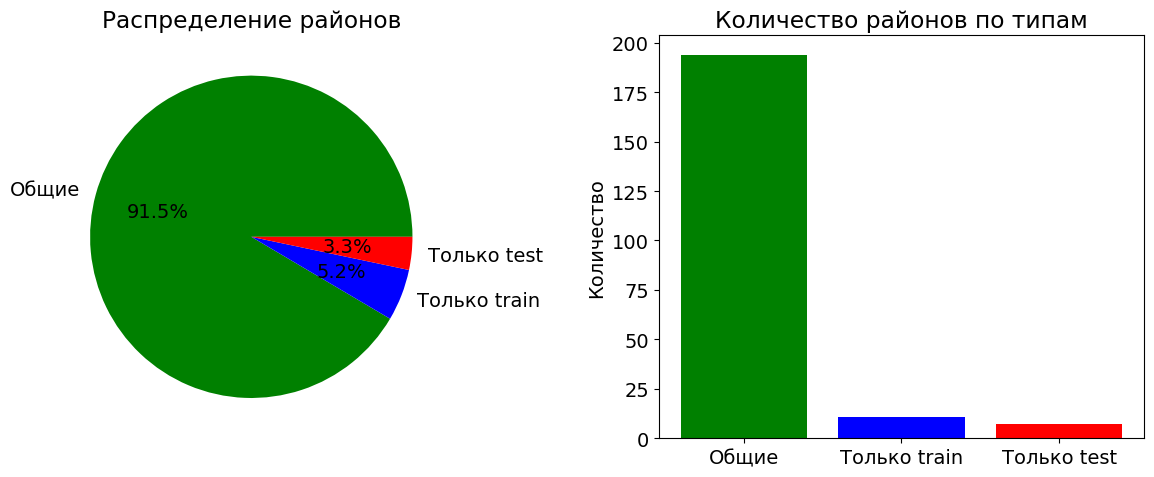

In [23]:
# Детальное сравнение
common_districts = train_districts.intersection(test_districts)
only_in_train = train_districts - test_districts
only_in_test = test_districts - train_districts

# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Круговые диаграммы
sizes = [len(common_districts), len(only_in_train), len(only_in_test)]
labels = ['Общие', 'Только train', 'Только test']
colors = ['green', 'blue', 'red']

ax1.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%')
ax1.set_title('Распределение районов')

# Столбчатая диаграмма
ax2.bar(labels, sizes, color=colors)
ax2.set_title('Количество районов по типам')
ax2.set_ylabel('Количество')

plt.tight_layout()
plt.show()

#### Заметим так же что в тестовых данных есть районы которых нет на обучении , поэтому придется их обработать

In [24]:
# ==================== ПОДГОТОВКА ДАННЫХ ДЛЯ ОБУЧЕНИЯ ====================
# Создаем копию данных
df_processed_train = df.copy()

# НОВЫЕ ПРИЗНАКИ: Взаимодействия (добавляем в самом начале)
df_processed_train['Rooms_Square_Ratio'] = df_processed_train['Rooms'] / df_processed_train['Square']
df_processed_train['LifeSquare_Ratio'] = df_processed_train['LifeSquare'] / df_processed_train['Square']

# На тренировочных данных вычисляем средние
target_encoding = df_processed_train.groupby('DistrictId')['Price'].mean()
price_per_sqm_by_district = df_processed_train.groupby('DistrictId')['Price'].mean() / df_processed_train.groupby('DistrictId')['Square'].mean()
room_means = df_processed_train.groupby(['DistrictId', 'Rooms'])['Price'].mean().reset_index()
room_means.rename(columns={'Price': 'Mean_Price_By_Rooms'}, inplace=True)

# НОВЫЙ ПРИЗНАК: Средняя цена за кв.м жилой площади по району и количеству комнат
life_square_means = df_processed_train.groupby(['DistrictId', 'Rooms']).apply(
    lambda x: x['Price'].mean() / x['LifeSquare'].mean() if x['LifeSquare'].mean() > 0 else 0
).reset_index()
life_square_means.rename(columns={0: 'Mean_Price_By_LifeSquare'}, inplace=True)

# НОВЫЙ ПРИЗНАК: Средняя цена за кв.м общей площади по району и количеству комнат
square_means = df_processed_train.groupby(['DistrictId', 'Rooms']).apply(
    lambda x: x['Price'].mean() / x['Square'].mean() if x['Square'].mean() > 0 else 0
).reset_index()
square_means.rename(columns={0: 'Mean_Price_By_Square'}, inplace=True)

train_target_encoding = target_encoding
train_price_per_sqm = price_per_sqm_by_district
train_room_means = room_means
train_life_square_means = life_square_means
train_square_means = square_means
train_district_means = df_processed_train.groupby('DistrictId')['Price'].mean()
train_overall_mean_price = df_processed_train['Price'].mean()

# Сохраняем средние для новых признаков взаимодействия
train_rooms_square_ratio_mean = df_processed_train['Rooms_Square_Ratio'].mean()
train_life_square_ratio_mean = df_processed_train['LifeSquare_Ratio'].mean()

# Создаем признаки
df_processed_train['DistrictId_TargetEnc'] = df_processed_train['DistrictId'].map(target_encoding)
df_processed_train['Avg_Price_Per_Sqm_By_District'] = df_processed_train['DistrictId'].map(price_per_sqm_by_district)

# Объединяем средние по комнатам
df_processed_train = df_processed_train.merge(room_means, on=['DistrictId', 'Rooms'], how='left')

# НОВЫЙ ПРИЗНАК: Объединяем средние по жилой площади
df_processed_train = df_processed_train.merge(life_square_means, on=['DistrictId', 'Rooms'], how='left')

# НОВЫЙ ПРИЗНАК: Объединяем средние по общей площади
df_processed_train = df_processed_train.merge(square_means, on=['DistrictId', 'Rooms'], how='left')

# Заполняем пропуски в новых признаках
overall_life_square_price = df_processed_train['Price'].mean() / df_processed_train['LifeSquare'].mean() if df_processed_train['LifeSquare'].mean() > 0 else 0
overall_square_price = df_processed_train['Price'].mean() / df_processed_train['Square'].mean() if df_processed_train['Square'].mean() > 0 else 0

if 'Mean_Price_By_LifeSquare' in df_processed_train.columns:
    df_processed_train['Mean_Price_By_LifeSquare'] = df_processed_train['Mean_Price_By_LifeSquare'].fillna(overall_life_square_price)
else:
    df_processed_train['Mean_Price_By_LifeSquare'] = overall_life_square_price

if 'Mean_Price_By_Square' in df_processed_train.columns:
    df_processed_train['Mean_Price_By_Square'] = df_processed_train['Mean_Price_By_Square'].fillna(overall_square_price)
else:
    df_processed_train['Mean_Price_By_Square'] = overall_square_price

# Заполняем пропуски в Mean_Price_By_Rooms
df_processed_train['Mean_Price_By_Rooms'] = df_processed_train['Mean_Price_By_Rooms'].fillna(
    df_processed_train['DistrictId'].map(train_district_means)
)

# Удаляем столбцы
columns_to_drop = ['Id', 'Healthcare_1','Ecology_1']
df_processed_train = df_processed_train.drop(columns=columns_to_drop)

# Подготовка категориальных признаков
categorical_columns = df_processed_train.select_dtypes(include=['object']).columns
for col in categorical_columns:
    df_processed_train[col] = df_processed_train[col].astype(str)

print("✅ ПРИЗНАКИ ДЛЯ ОБУЧЕНИЯ ПОДГОТОВЛЕНЫ")
print(f"Добавлены новые признаки:")
print(f"DistrictId_TargetEnc - средняя цена квартир в каждом районе (таргет-энкодинг по DistrictId)")
print(f"Mean_Price_By_Rooms - средняя цена квартир по комбинации 'район + количество комнат'")
print(f"Mean_Price_By_Square - средняя цена за кв.м общей площади по 'район + комнаты'")
print(f"Mean_Price_By_LifeSquare - средняя цена за кв.м ЖИЛОЙ площади по 'район + комнаты'")
print(f"Avg_Price_Per_Sqm_By_District - средняя цена за кв.м по районам (без учета комнат)")
print(f"LifeSquare_Ratio - доля жилой площади от общей (эффективность планировки)")
print(f"Rooms_Square_Ratio - плотность комнат (количество комнат на кв.метр)")


✅ ПРИЗНАКИ ДЛЯ ОБУЧЕНИЯ ПОДГОТОВЛЕНЫ
Добавлены новые признаки:
DistrictId_TargetEnc - средняя цена квартир в каждом районе (таргет-энкодинг по DistrictId)
Mean_Price_By_Rooms - средняя цена квартир по комбинации 'район + количество комнат'
Mean_Price_By_Square - средняя цена за кв.м общей площади по 'район + комнаты'
Mean_Price_By_LifeSquare - средняя цена за кв.м ЖИЛОЙ площади по 'район + комнаты'
Avg_Price_Per_Sqm_By_District - средняя цена за кв.м по районам (без учета комнат)
LifeSquare_Ratio - доля жилой площади от общей (эффективность планировки)
Rooms_Square_Ratio - плотность комнат (количество комнат на кв.метр)


### 3. Обучим основную модель

In [25]:
# ==================== ОБУЧЕНИЕ МОДЕЛИ ====================
# Определение фичей и таргета
target = 'Price'
features = [col for col in df_processed_train.columns if col != target]

# Определение категориальных фичей
cat_features = [i for i, col in enumerate(features) if df_processed_train[col].dtype == "object"]

# Разделение на train/valid
X_train, X_valid, y_train, y_valid = train_test_split(
    df_processed_train[features], df_processed_train[target],
    test_size=0.2, random_state=42
)

# Создание Pool объектов
train_pool = Pool(X_train, y_train, cat_features=cat_features)
valid_pool = Pool(X_valid, y_valid, cat_features=cat_features)

# Инициализация и обучение модели
model = CatBoostRegressor(
    iterations=2485,
    learning_rate=0.029549747271183396,
    depth=9,
    random_strength=1.9953320231752796,
    l2_leaf_reg=1.0264175004776102,
    one_hot_max_size=52,
    verbose=200,
    bagging_temperature=1.4408569297842215,
    random_state=42,
    eval_metric='RMSE'
)

print("Начинаем обучение модели...")
model.fit(train_pool, eval_set=valid_pool, early_stopping_rounds=100)

# Предсказание на валидации
pred_valid = model.predict(valid_pool)

# Метрики
print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ ОБУЧЕНИЯ:")
print("="*50)
print(f"MAE: {mean_absolute_error(y_valid, pred_valid):.2f}")
print(f"R2: {r2_score(y_valid, pred_valid):.4f}")
print("="*50)

Начинаем обучение модели...
0:	learn: 90353.5928130	test: 94475.1469630	best: 94475.1469630 (0)	total: 11.7ms	remaining: 29.1s
200:	learn: 36988.1853319	test: 48338.6106686	best: 48338.6106686 (200)	total: 1.48s	remaining: 16.8s
400:	learn: 31098.3647196	test: 47293.7767387	best: 47284.9117770 (396)	total: 2.86s	remaining: 14.9s
600:	learn: 26419.9791306	test: 46978.6179963	best: 46978.3529792 (578)	total: 4.3s	remaining: 13.5s
800:	learn: 22995.2379671	test: 46949.5575834	best: 46905.6609350 (729)	total: 5.82s	remaining: 12.2s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 46905.66094
bestIteration = 729

Shrink model to first 730 iterations.

РЕЗУЛЬТАТЫ ОБУЧЕНИЯ:
MAE: 27191.52
R2: 0.7615


In [26]:
# Посмотрим кореляцию признаков
df_processed_train.corr().style.background_gradient(cmap='coolwarm').format('{:.2f}')

,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_2,Ecology_3,Social_1,Social_2,Social_3,Helthcare_2,Shops_1,Shops_2,Price,Rooms_Square_Ratio,LifeSquare_Ratio,DistrictId_TargetEnc,Avg_Price_Per_Sqm_By_District,Mean_Price_By_Rooms,Mean_Price_By_LifeSquare,Mean_Price_By_Square
DistrictId,1.00,0.07,-0.03,-0.09,0.04,-0.12,-0.15,-0.20,0.09,0.03,0.25,0.17,0.14,0.31,0.17,0.02,0.27,0.07,-0.10,0.45,0.50,0.33,0.47,0.48
Rooms,0.07,1.00,0.66,0.51,0.01,-0.00,-0.03,-0.04,0.00,0.01,0.08,0.07,0.01,0.06,0.05,0.00,0.55,0.39,0.06,0.15,0.11,0.69,-0.13,-0.04
Square,-0.03,0.66,1.00,0.77,0.01,0.11,0.08,0.18,-0.03,-0.02,-0.07,-0.04,0.04,-0.02,0.02,0.05,0.52,-0.03,0.03,0.05,-0.06,0.48,-0.25,-0.18
LifeSquare,-0.09,0.51,0.77,1.00,-0.01,0.11,0.08,0.13,-0.03,-0.04,-0.19,-0.16,0.07,-0.10,-0.00,0.05,0.32,0.00,0.46,-0.07,-0.17,0.30,-0.38,-0.26
KitchenSquare,0.04,0.01,0.01,-0.01,1.00,-0.01,0.00,0.04,-0.00,0.01,0.04,0.04,-0.02,0.04,0.01,0.02,0.03,-0.01,-0.03,0.04,0.04,0.03,0.05,0.04
Floor,-0.12,-0.00,0.11,0.11,-0.01,1.00,0.42,0.28,-0.05,-0.03,-0.04,-0.02,-0.00,-0.07,0.02,0.01,0.13,-0.08,0.04,-0.01,-0.07,0.01,-0.09,-0.07
HouseFloor,-0.15,-0.03,0.08,0.08,0.00,0.42,1.00,0.39,-0.06,-0.01,-0.02,0.01,-0.01,-0.07,0.03,-0.05,0.09,-0.11,0.03,-0.04,-0.08,-0.02,-0.08,-0.07
HouseYear,-0.20,-0.04,0.18,0.13,0.04,0.28,0.39,1.00,-0.08,-0.05,-0.05,0.01,-0.05,-0.12,-0.00,0.06,0.04,-0.16,0.02,-0.14,-0.23,-0.09,-0.20,-0.22
Ecology_2,0.09,0.00,-0.03,-0.03,-0.00,-0.05,-0.06,-0.08,1.00,-0.02,0.07,0.01,-0.01,0.08,-0.05,0.02,-0.02,0.02,-0.01,-0.03,0.02,-0.02,0.03,0.02
Ecology_3,0.03,0.01,-0.02,-0.04,0.01,-0.03,-0.01,-0.05,-0.02,1.00,0.04,-0.01,-0.01,0.13,-0.00,-0.05,0.05,0.02,-0.03,0.09,0.11,0.06,0.12,0.11


In [27]:
# Сравнение обученой модели с реальными ценами
comparison = pd.DataFrame({
    "Price_real": y_valid,
    "Price_pred": pred_valid
})

comparison.head(20) 

,Price_real,Price_pred
4122,281986.00,199186.087254
4065,238492.08,218270.556916
1731,180382.20,172480.294118
4740,257211.14,234552.391666
6391,89917.92,186678.705160
4376,274398.62,244791.836367
576,377445.10,316113.760672
6837,339844.47,299858.557850
4359,133632.34,138849.301557
439,184036.00,176592.831824


### 4. Для предсказания введем новые признаки в тестовый датасет и обработаем пропуски, так как в тесте есть новые районы

In [28]:
# ==================== ПОДГОТОВКА ПРИЗНАКОВ ДЛЯ ПРЕДСКАЗАНИЯ ====================

# Создаем копию тестовых данных
df_processed_test = df_test.copy()

# НОВЫЕ ПРИЗНАКИ: Взаимодействия для теста (добавляем в самом начале)
df_processed_test['Rooms_Square_Ratio'] = df_processed_test['Rooms'] / df_processed_test['Square']
df_processed_test['LifeSquare_Ratio'] = df_processed_test['LifeSquare'] / df_processed_test['Square']

# Сохраняем общие средние с тренировки для заполнения пропусков
train_overall_mean_price = df['Price'].mean()
train_overall_price_per_sqm = df['Price'].mean() / df['Square'].mean() if df['Square'].mean() > 0 else 0
train_overall_life_square_price = df['Price'].mean() / df['LifeSquare'].mean() if df['LifeSquare'].mean() > 0 else 0
train_overall_square_price = df['Price'].mean() / df['Square'].mean() if df['Square'].mean() > 0 else 0
train_rooms_square_ratio_mean = df['Rooms_Square_Ratio'].mean() if 'Rooms_Square_Ratio' in df.columns else 0
train_life_square_ratio_mean = df['LifeSquare_Ratio'].mean() if 'LifeSquare_Ratio' in df.columns else 0

# На тестовых данных используем средние с тренировочных данных
df_processed_test['DistrictId_TargetEnc'] = df_processed_test['DistrictId'].map(train_target_encoding)
df_processed_test['Avg_Price_Per_Sqm_By_District'] = df_processed_test['DistrictId'].map(train_price_per_sqm)

# ПРОВЕРКА И ЗАПОЛНЕНИЕ ПРОПУСКОВ В DistrictId_TargetEnc ДЛЯ ТЕСТА
missing_district_enc_test = df_processed_test['DistrictId_TargetEnc'].isna().sum()
if missing_district_enc_test > 0:
    print(f"⚠️ Заполняем {missing_district_enc_test} пропусков в DistrictId_TargetEnc (тест) общим средним значением с тренировки")
    df_processed_test['DistrictId_TargetEnc'] = df_processed_test['DistrictId_TargetEnc'].fillna(train_overall_mean_price)

# Объединяем средние по комнатам
df_processed_test = df_processed_test.merge(train_room_means, on=['DistrictId', 'Rooms'], how='left')

# НОВЫЙ ПРИЗНАК: Объединяем средние по жилой площади
df_processed_test = df_processed_test.merge(train_life_square_means, on=['DistrictId', 'Rooms'], how='left')

# НОВЫЙ ПРИЗНАК: Объединяем средние по общей площади
df_processed_test = df_processed_test.merge(train_square_means, on=['DistrictId', 'Rooms'], how='left')

# ЗАПОЛНЯЕМ ПРОПУСКИ ВО ВСЕХ ПРИЗНАКАХ ПОСЛЕ MERGE
print("🔍 ЗАПОЛНЕНИЕ ПРОПУСКОВ В ПРИЗНАКАХ:")

# Заполняем Mean_Price_By_Rooms (сначала через district_means, потом общим средним)
df_processed_test['Mean_Price_By_Rooms'] = df_processed_test['Mean_Price_By_Rooms'].fillna(
    df_processed_test['DistrictId'].map(train_district_means)
)
# Если после этого остались пропуски (новые DistrictId), заполняем общим средним
remaining_missing = df_processed_test['Mean_Price_By_Rooms'].isna().sum()
if remaining_missing > 0:
    print(f"⚠️ Заполняем {remaining_missing} оставшихся пропусков в Mean_Price_By_Rooms общим средним")
    df_processed_test['Mean_Price_By_Rooms'] = df_processed_test['Mean_Price_By_Rooms'].fillna(train_overall_mean_price)

# Заполняем Mean_Price_By_LifeSquare
if 'Mean_Price_By_LifeSquare' in df_processed_test.columns:
    df_processed_test['Mean_Price_By_LifeSquare'] = df_processed_test['Mean_Price_By_LifeSquare'].fillna(train_overall_life_square_price)
else:
    df_processed_test['Mean_Price_By_LifeSquare'] = train_overall_life_square_price

# Заполняем Mean_Price_By_Square
if 'Mean_Price_By_Square' in df_processed_test.columns:
    df_processed_test['Mean_Price_By_Square'] = df_processed_test['Mean_Price_By_Square'].fillna(train_overall_square_price)
else:
    df_processed_test['Mean_Price_By_Square'] = train_overall_square_price

# Заполняем новые признаки взаимодействия
if 'Rooms_Square_Ratio' in df_processed_test.columns:
    df_processed_test['Rooms_Square_Ratio'] = df_processed_test['Rooms_Square_Ratio'].fillna(train_rooms_square_ratio_mean)

if 'LifeSquare_Ratio' in df_processed_test.columns:
    df_processed_test['LifeSquare_Ratio'] = df_processed_test['LifeSquare_Ratio'].fillna(train_life_square_ratio_mean)

# Заполняем Avg_Price_Per_Sqm_By_District
df_processed_test['Avg_Price_Per_Sqm_By_District'] = df_processed_test['Avg_Price_Per_Sqm_By_District'].fillna(train_overall_price_per_sqm)

# Удаляем столбцы
df_processed_test = df_processed_test.drop(columns=columns_to_drop)

# Подготовка категориальных признаков
categorical_columns_test = df_processed_test.select_dtypes(include=['object']).columns
for col in categorical_columns_test:
    df_processed_test[col] = df_processed_test[col].astype(str)

# ФИНАЛЬНАЯ ПРОВЕРКА ПРОПУСКОВ
print("\n📊 ФИНАЛЬНАЯ ПРОВЕРКА ПРОПУСКОВ:")
missing_columns = []
for column in df_processed_test.columns:
    missing_count = df_processed_test[column].isna().sum()
    if missing_count > 0:
        missing_columns.append((column, missing_count))
        print(f"❌ В {column} осталось {missing_count} пропусков")
    else:
        print(f"✅ {column} - пропусков нет")

if not missing_columns:
    print("🎉 ВСЕ ПРОПУСКИ УСПЕШНО ЗАПОЛНЕНЫ!")
else:
    print(f"⚠️ Остались пропуски в {len(missing_columns)} столбцах")

print("✅ ПРИЗНАКИ ДЛЯ ТЕСТА ПОДГОТОВЛЕНЫ")
print(f"Добавлены новые признаки: Rooms_Square_Ratio, LifeSquare_Ratio, Mean_Price_By_Square")

⚠️ Заполняем 8 пропусков в DistrictId_TargetEnc (тест) общим средним значением с тренировки
🔍 ЗАПОЛНЕНИЕ ПРОПУСКОВ В ПРИЗНАКАХ:
⚠️ Заполняем 8 оставшихся пропусков в Mean_Price_By_Rooms общим средним

📊 ФИНАЛЬНАЯ ПРОВЕРКА ПРОПУСКОВ:
✅ DistrictId - пропусков нет
✅ Rooms - пропусков нет
✅ Square - пропусков нет
✅ LifeSquare - пропусков нет
✅ KitchenSquare - пропусков нет
✅ Floor - пропусков нет
✅ HouseFloor - пропусков нет
✅ HouseYear - пропусков нет
✅ Ecology_2 - пропусков нет
✅ Ecology_3 - пропусков нет
✅ Social_1 - пропусков нет
✅ Social_2 - пропусков нет
✅ Social_3 - пропусков нет
✅ Helthcare_2 - пропусков нет
✅ Shops_1 - пропусков нет
✅ Shops_2 - пропусков нет
✅ Rooms_Square_Ratio - пропусков нет
✅ LifeSquare_Ratio - пропусков нет
✅ DistrictId_TargetEnc - пропусков нет
✅ Avg_Price_Per_Sqm_By_District - пропусков нет
✅ Mean_Price_By_Rooms - пропусков нет
✅ Mean_Price_By_LifeSquare - пропусков нет
✅ Mean_Price_By_Square - пропусков нет
🎉 ВСЕ ПРОПУСКИ УСПЕШНО ЗАПОЛНЕНЫ!
✅ ПРИЗНАКИ ДЛЯ 

In [29]:
# ==================== ЗАПУСК ПРЕДСКАЗАНИЯ ====================

# Создание Pool для теста
test_pool = Pool(df_processed_test[features], cat_features=cat_features)

# Предсказание
pred_test = model.predict(test_pool)

# Создание результата
df_processed_test["Predicted_Price"] = pred_test
results = pd.DataFrame({
    #"Id": df_processed_test['Id'],
    "Price_pred": df_processed_test['Predicted_Price']
})

print(f"\n📊 Всего предсказано: {len(results)} записей")


📊 Всего предсказано: 5000 записей


In [30]:
results.head(20)

,Price_pred
0,152457.376021
1,232875.693801
2,272849.864488
3,275471.472180
4,142474.450951
5,209022.136723
6,162264.490353
7,225083.312833
8,290732.206085
9,195971.694695


In [31]:
results.to_csv('OKorbovsky_predictions.csv')

In [32]:
df_processed_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9997 entries, 0 to 9996
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   DistrictId                     9997 non-null   int64  
 1   Rooms                          9997 non-null   float64
 2   Square                         9997 non-null   float64
 3   LifeSquare                     9997 non-null   float64
 4   KitchenSquare                  9997 non-null   float64
 5   Floor                          9997 non-null   int64  
 6   HouseFloor                     9997 non-null   float64
 7   HouseYear                      9997 non-null   int64  
 8   Ecology_2                      9997 non-null   int64  
 9   Ecology_3                      9997 non-null   int64  
 10  Social_1                       9997 non-null   int64  
 11  Social_2                       9997 non-null   int64  
 12  Social_3                       9997 non-null   i

In [33]:
df_processed_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   DistrictId                     5000 non-null   int64  
 1   Rooms                          5000 non-null   float64
 2   Square                         5000 non-null   float64
 3   LifeSquare                     5000 non-null   float64
 4   KitchenSquare                  5000 non-null   float64
 5   Floor                          5000 non-null   int64  
 6   HouseFloor                     5000 non-null   float64
 7   HouseYear                      5000 non-null   int64  
 8   Ecology_2                      5000 non-null   int64  
 9   Ecology_3                      5000 non-null   int64  
 10  Social_1                       5000 non-null   int64  
 11  Social_2                       5000 non-null   int64  
 12  Social_3                       5000 non-null   i

#### Вывод:

**восстановлениe признака LifeSquare сыграло не большую роль на качестве модели, восстановление признака Helthcare_1 влияния не оказало, и он был удален! На повышение качества R2 оказало влияние введение новоых признаков привязанях к общей цене по району! Так же подбор гиперпараметров, а так же то что модель CatBoostRegressor сама отсекает переобучение (early_stopping_rounds=100) и мультиколениарность!**

**Итоговый результат:**

**MAE: 27191.52**

**R2: 0.7615**

### 5. Сравнение с другими моделями в базовой настройке

In [34]:
# Протестим для GradientBoostingRegressor

In [35]:
# Определение фичей и таргета
target = 'Price'
features = [col for col in df_processed_train.columns if col != target]

# Определение категориальных фичей
cat_features = [i for i, col in enumerate(features) if df_processed_train[col].dtype == "object"]

# Разделение на train/valid
X_train, X_valid, y_train, y_valid = train_test_split(
    df_processed_train[features], df_processed_train[target],
    test_size=0.2, random_state=42
)

# Создание Pool объектов
#train_pool = Pool(X_train, y_train, cat_features=cat_features)
#valid_pool = Pool(X_valid, y_valid, cat_features=cat_features)

# ====== Модель Gradient Boosting ======
model = GradientBoostingRegressor(
    n_estimators=600,          # количество слабых моделей (деревьев)
    learning_rate=0.03,        # скорость обучения
    max_depth=3,               # глубина каждого дерева
    subsample=0.8,             # стохастический бустинг, уменьшает переобучение
    random_state=42
)
model.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.03, n_estimators=600, random_state=42,
                          subsample=0.8)

In [36]:
preds = model.predict(X_valid)

In [37]:
print(f"MAE: {mean_absolute_error(y_valid, preds):.2f}")
print(f"R2: {r2_score(y_valid, preds):.4f}")

MAE: 28524.71
R2: 0.7509


In [38]:
# Протестим для RandomForestRegressor

In [39]:
# Определение фичей и таргета
target = 'Price'
features = [col for col in df_processed_train.columns if col != target]

# Определение категориальных фичей
cat_features = [i for i, col in enumerate(features) if df_processed_train[col].dtype == "object"]

# Разделение на train/valid
X_train, X_valid, y_train, y_valid = train_test_split(
    df_processed_train[features], df_processed_train[target],
    test_size=0.2, random_state=42
)

model = RandomForestRegressor(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

RandomForestRegressor(min_samples_leaf=2, n_estimators=400, n_jobs=-1,
                      random_state=42)

In [40]:
preds = model.predict(X_valid)

In [41]:
print(f"MAE: {mean_absolute_error(y_valid, preds):.2f}")
print(f"R2: {r2_score(y_valid, preds):.4f}")

MAE: 27873.45
R2: 0.7445


In [42]:
# Для LinearRegression

In [43]:
target = 'Price'
features = [col for col in df_processed_train.columns if col != target]

# Разделение на train/valid
X_train, X_valid, y_train, y_valid = train_test_split(
    df_processed_train[features], df_processed_train[target],
    test_size=0.2, random_state=42
)

print("Размеры данных:")
print(f"X_train: {X_train.shape}, X_valid: {X_valid.shape}")
print(f"y_train: {y_train.shape}, y_valid: {y_valid.shape}")

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

Размеры данных:
X_train: (7997, 23), X_valid: (2000, 23)
y_train: (7997,), y_valid: (2000,)


LinearRegression()

In [44]:
# Предсказание
y_pred = model_lr.predict(X_valid)

In [45]:
# Метрики
mae_lr = mean_absolute_error(y_valid, y_pred)
r2_lr = r2_score(y_valid, y_pred)

print(f"MAE: {mae_lr:.2f}")
print(f"R2: {r2_lr:.4f}")


MAE: 34353.54
R2: 0.6793


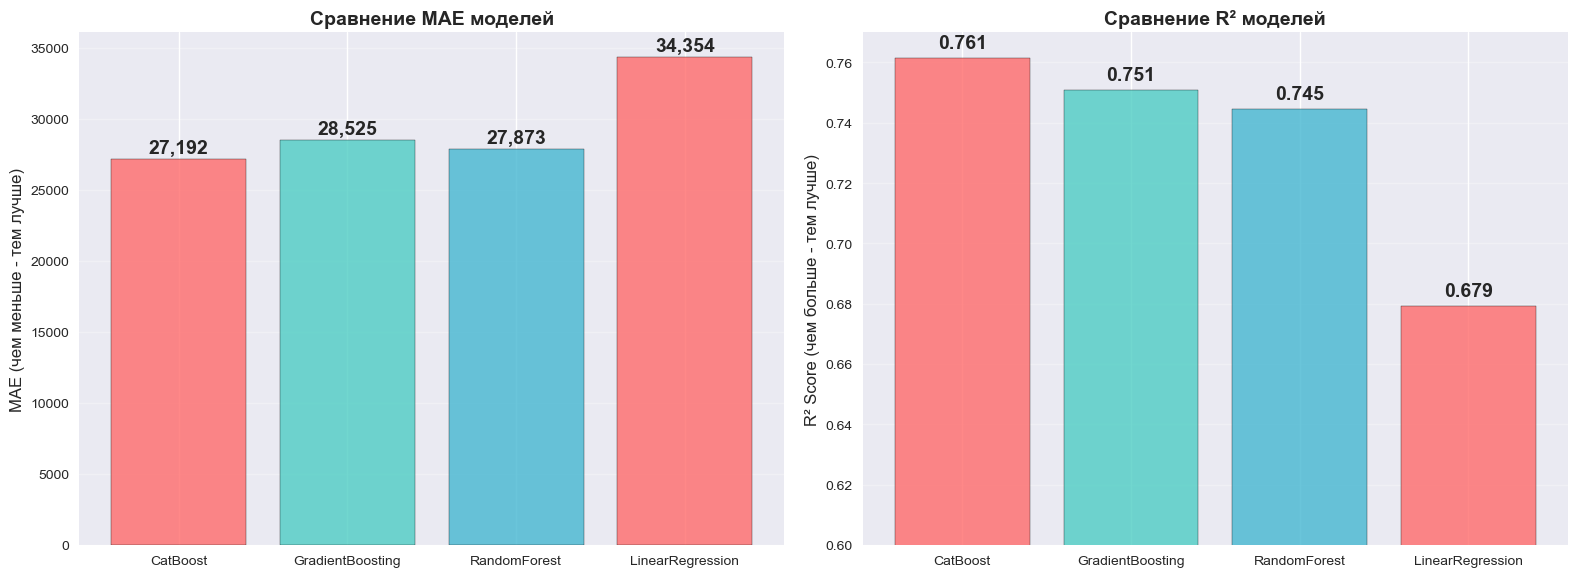

In [48]:
# Данные моделей
models_data = {
    'Model': ['CatBoost', 'GradientBoosting', 'RandomForest', 'LinearRegression'],
    'MAE': [27191.52, 28524.71, 27873.45, 34353.54],
    'R2': [0.7615, 0.7509, 0.7445, 0.6793]
}

df_models = pd.DataFrame(models_data)

# Настройка стиля
plt.style.use('seaborn-v0_8')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Цвета для моделей
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

# График MAE
bars1 = ax1.bar(df_models['Model'], df_models['MAE'], color=colors, alpha=0.8, edgecolor='black')
ax1.set_title('Сравнение MAE моделей', fontsize=14, fontweight='bold')
ax1.set_ylabel('MAE (чем меньше - тем лучше)', fontsize=12)
ax1.grid(axis='y', alpha=0.3)

# Добавление значений на столбцы
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 100,
            f'{height:,.0f}', ha='center', va='bottom', fontweight='bold')

# График R²
bars2 = ax2.bar(df_models['Model'], df_models['R2'], color=colors, alpha=0.8, edgecolor='black')
ax2.set_title('Сравнение R² моделей', fontsize=14, fontweight='bold')
ax2.set_ylabel('R² Score (чем больше - тем лучше)', fontsize=12)
ax2.set_ylim(0.60, 0.77)
ax2.grid(axis='y', alpha=0.3)

# Добавление значений на столбцы
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.002,
            f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()
